In [ ]:
from google.colab import files

uploaded = files.upload()


Saving cropped_dataset.zip to cropped_dataset.zip


In [ ]:
import zipfile
from pathlib import Path

# ZIP file name (change if your zip has a different name)
zip_path = Path("/content/cropped_dataset.zip")

# Output folder where files will be extracted
unzip_dir = Path("/content/Dataset")

unzip_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(unzip_dir)

print("Dataset unzipped successfully!")
print("Extracted folder contents:")
!ls /content/Dataset


Dataset unzipped successfully!
Extracted folder contents:
cropped_dataset


Found 41 images in /content/Dataset


Processing images:   0%|          | 0/41 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/usr/local/lib/python3.12/dist-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
Processing images: 100%|██████████| 41/41 [00:19<00:00,  2.08it/s]


Processing complete.
Saved results to: enhanced_fingerprint_dataset


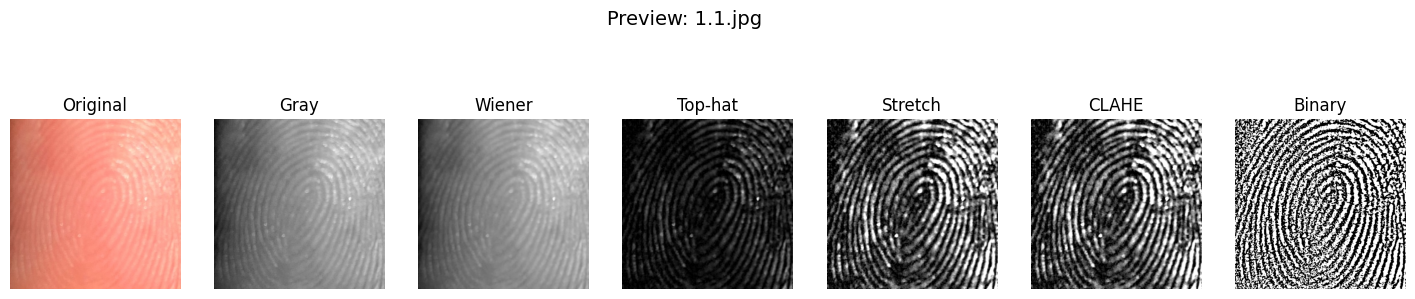

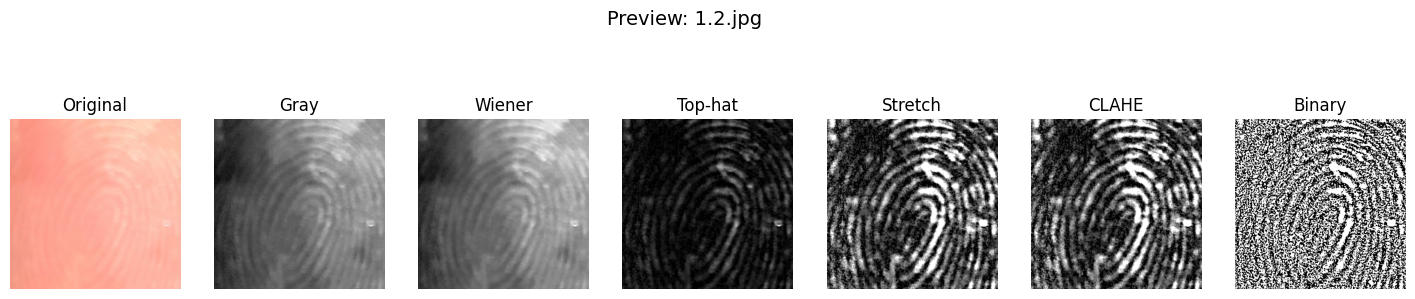

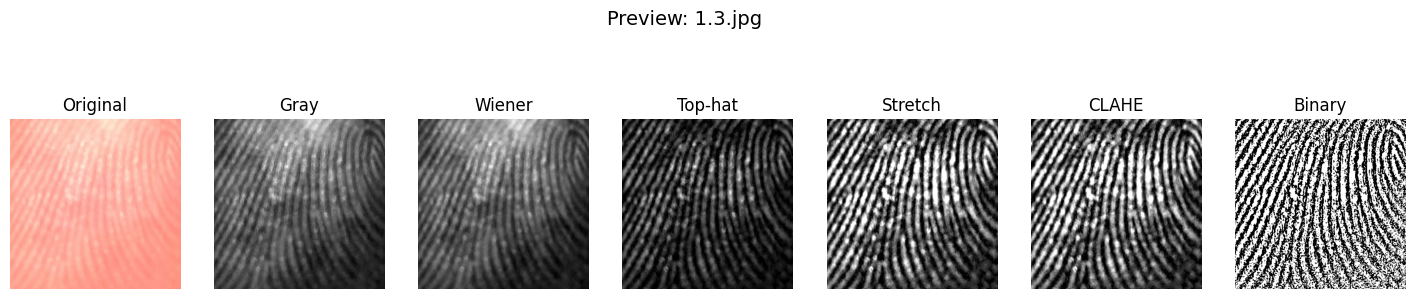

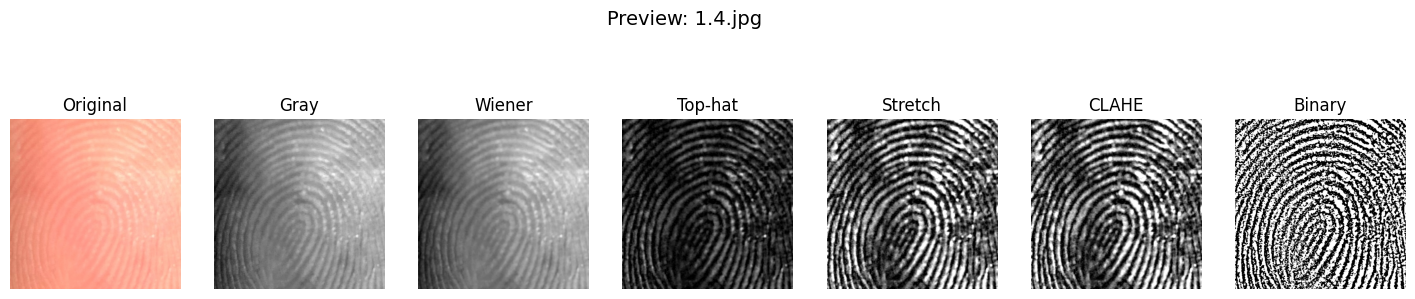

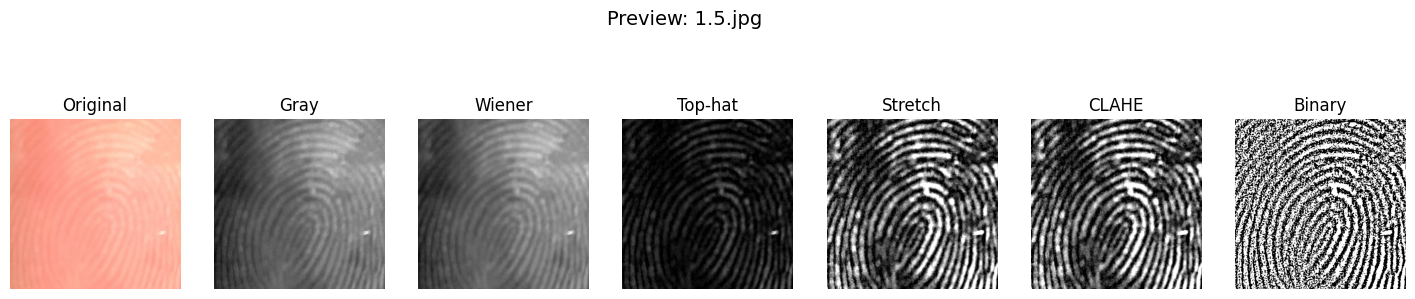

In [ ]:
# requirements:
# pip install pillow tqdm scikit-image opencv-python scipy matplotlib --quiet

from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import os

from scipy.signal import wiener
from skimage.morphology import disk, white_tophat
from skimage import exposure

# ---------------------------
# USER CONFIG
# ---------------------------
INPUT_DIR  = Path("/content/Dataset")   # change this
OUTPUT_DIR = Path("enhanced_fingerprint_dataset")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

# Step folders
STEP1_DIR = OUTPUT_DIR / "step1_gray"
STEP2_DIR = OUTPUT_DIR / "step2_wiener"
STEP3_DIR = OUTPUT_DIR / "step3_tophat"
STEP4_DIR = OUTPUT_DIR / "step4_stretch"
STEP5_DIR = OUTPUT_DIR / "step5_CLAHE"
STEP6_DIR = OUTPUT_DIR / "step6_binary"

for d in (STEP1_DIR, STEP2_DIR, STEP3_DIR, STEP4_DIR, STEP5_DIR, STEP6_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---------------------------
# HELPER FUNCTIONS
# ---------------------------

def safe_name_from_path(p: Path, base: Path):
    rel = p.relative_to(base)
    rel_str = str(rel)
    safe = rel_str.replace(os.sep, "__").replace("/", "__").replace(" ", "_")
    return safe

def fingerprint_enhancement_pipeline(img_rgb):
    """
    Full fingerprint enhancement pipeline.
    Input: RGB image (uint8)
    Returns: gray, wiener_img, tophat_img, stretched, clahe_img, binary_img
    """

    # 1️⃣ Convert to Grayscale
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # 2️⃣ Wiener Denoising
    wiener_img = wiener(gray.astype(float), (3, 3))
    wiener_img = np.clip(wiener_img, 0, 255).astype(np.uint8)

    # 3️⃣ Top-hat (Enhance ridges)
    selem = disk(15)
    tophat_img = white_tophat(wiener_img, selem)
    tophat_img = np.clip(tophat_img, 0, 255).astype(np.uint8)

    # 4️⃣ Contrast Stretching
    p_low, p_high = np.percentile(tophat_img, (5, 95))
    if p_low != p_high:
        stretched = exposure.rescale_intensity(
            tophat_img, in_range=(p_low, p_high), out_range=(0, 255)
        ).astype(np.uint8)
    else:
        stretched = tophat_img.copy()

    # 5️⃣ CLAHE (Strong contrast enhancement)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(stretched)

    # 6️⃣ Adaptive Threshold (Binarization)
    binary_img = cv2.adaptiveThreshold(
        clahe_img,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    return gray, wiener_img, tophat_img, stretched, clahe_img, binary_img


# ---------------------------
# COLLECT INPUT FILES
# ---------------------------
files = [p for p in INPUT_DIR.rglob("*") if p.suffix.lower() in EXTS]
files = sorted(files)
print(f"Found {len(files)} images in {INPUT_DIR}")

# ---------------------------
# PROCESS IMAGES
# ---------------------------
preview_list = []

for idx, img_path in enumerate(tqdm(files, desc="Processing images")):

    safe_name = safe_name_from_path(img_path, INPUT_DIR)
    stem = Path(safe_name).stem

    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"Error reading {img_path}")
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    try:
        gray, wiener_img, tophat_img, stretched, clahe_img, binary_img = fingerprint_enhancement_pipeline(img_rgb)
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        continue

    # Save each step
    Image.fromarray(gray).save(STEP1_DIR / f"{stem}_gray.png")
    Image.fromarray(wiener_img).save(STEP2_DIR / f"{stem}_wiener.png")
    Image.fromarray(tophat_img).save(STEP3_DIR / f"{stem}_tophat.png")
    Image.fromarray(stretched).save(STEP4_DIR / f"{stem}_stretch.png")
    Image.fromarray(clahe_img).save(STEP5_DIR / f"{stem}_clahe.png")
    Image.fromarray(binary_img).save(STEP6_DIR / f"{stem}_binary.png")

    if idx < 5:
        preview_list.append((img_path.name, img_rgb, gray, wiener_img,
                             tophat_img, stretched, clahe_img, binary_img))

print("Processing complete.")
print("Saved results to:", OUTPUT_DIR)

# ---------------------------
# SHOW PREVIEW (FIRST 5)
# ---------------------------
for item in preview_list:
    (name, img_rgb, gray, wiener_img,
     tophat_img, stretched, clahe_img, binary_img) = item

    titles = ["Original", "Gray", "Wiener", "Top-hat",
              "Stretch", "CLAHE", "Binary"]

    images = [img_rgb, gray, wiener_img,
              tophat_img, stretched, clahe_img, binary_img]

    plt.figure(figsize=(18, 4))
    plt.suptitle(f"Preview: {name}", fontsize=14)

    for j, (title, img) in enumerate(zip(titles, images)):
        plt.subplot(1, len(images), j+1)

        if img.ndim == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)

        plt.title(title)
        plt.axis("off")

    plt.show()

Found 41 images in enhanced_fingerprint_dataset/step5_CLAHE


Processing images: 100%|██████████| 41/41 [00:01<00:00, 22.92it/s]


Saved binaries to: fx_bin_skel_outputs/binary_clean
Saved skeletons to: fx_bin_skel_outputs/skeleton


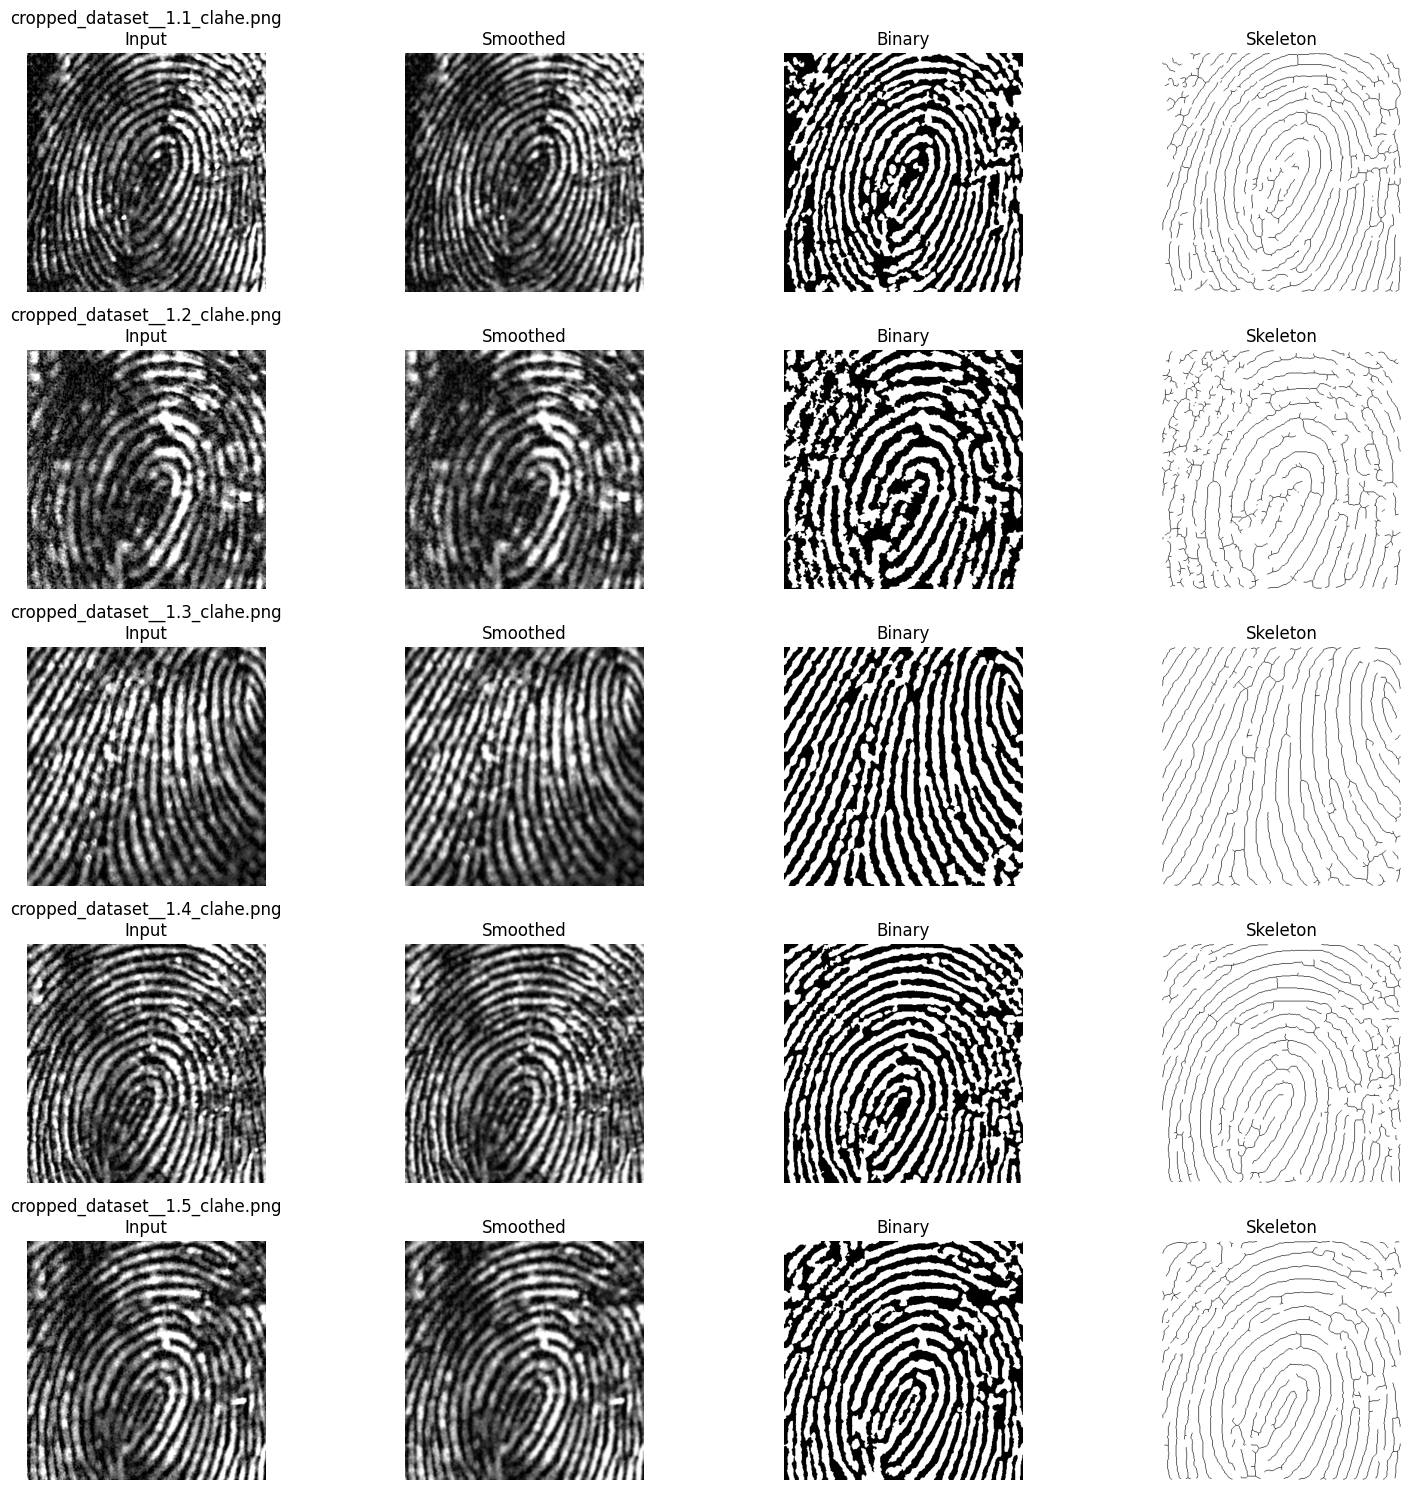

In [ ]:
# ============================================================
# COMPLETE BATCH BINARIZATION + SKELETONIZATION PIPELINE
# Stable Version (No Common Errors)
# ============================================================
# pip install -q scikit-image opencv-python matplotlib numpy tqdm

import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize, remove_small_objects, remove_small_holes
from skimage.filters import threshold_sauvola
from tqdm import tqdm

# ---------------- USER CONFIG ----------------
INPUT_DIR  = Path("enhanced_fingerprint_dataset/step5_CLAHE")  # CHANGE THIS
OUTPUT_DIR = Path("fx_bin_skel_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BINARY_DIR   = OUTPUT_DIR / "binary_clean"
SKELETON_DIR = OUTPUT_DIR / "skeleton"
BINARY_DIR.mkdir(exist_ok=True)
SKELETON_DIR.mkdir(exist_ok=True)

PATTERN = "*.png"   # process all png images

# PARAMETERS
GAUSSIAN_KERNEL = (5, 5)
K = 0.12
MIN_OBJ_SIZE = 120
HOLE_AREA_THRESH = 120
CLOSE_KERNEL = np.ones((3, 3), np.uint8)
MAX_PREVIEW = 5

# ---------------- FIND FILES ----------------
files = sorted(INPUT_DIR.rglob(PATTERN))
print(f"Found {len(files)} images in {INPUT_DIR}")

if len(files) == 0:
    print("No images found. Check INPUT_DIR.")
    raise SystemExit()

preview = []

# ---------------- PROCESS LOOP ----------------
for p in tqdm(files, desc="Processing images"):

    try:
        # 1️⃣ LOAD IMAGE SAFELY
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None:
            print("Cannot read:", p)
            continue

        img = img.astype(np.uint8)

        # 2️⃣ NORMALIZE (Safe)
        img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

        # 3️⃣ SMOOTH
        smooth = cv2.GaussianBlur(img_norm, GAUSSIAN_KERNEL, 0)

        # 4️⃣ ADAPTIVE WINDOW SIZE (avoid Sauvola crash)
        min_dim = min(smooth.shape)
        window_size = min(31, min_dim - 1)
        if window_size % 2 == 0:
            window_size -= 1
        if window_size < 15:
            window_size = 15

        # 5️⃣ SAUVOLA THRESHOLD
        try:
            th_sauv = threshold_sauvola(smooth, window_size=window_size, k=K)
            binary_bool = smooth > th_sauv
        except Exception:
            # Fallback to OpenCV adaptive
            binary_ad = cv2.adaptiveThreshold(
                smooth, 255,
                cv2.ADAPTIVE_THRESH_MEAN_C,
                cv2.THRESH_BINARY,
                31, 5
            )
            binary_bool = binary_ad > 0

        # 6️⃣ Fallback if too sparse
        if binary_bool.sum() < 50:
            _, otsu = cv2.threshold(
                smooth, 0, 255,
                cv2.THRESH_BINARY + cv2.THRESH_OTSU
            )
            binary_bool = otsu > 0

        # 7️⃣ REMOVE SMALL NOISE
        clean = remove_small_objects(binary_bool.astype(bool),
                                     min_size=MIN_OBJ_SIZE)
        clean = remove_small_holes(clean,
                                   area_threshold=HOLE_AREA_THRESH)

        binary_clean = (clean.astype(np.uint8) * 255)

        # 8️⃣ INVERT (black ridges on white)
        ink_thick = 255 - binary_clean

        # 9️⃣ MORPHOLOGICAL CLOSE
        ink_thick = cv2.morphologyEx(
            ink_thick, cv2.MORPH_CLOSE,
            CLOSE_KERNEL, iterations=1
        )

        # 🔟 SKELETONIZATION
        skel_bool = (ink_thick == 0)  # ridges True
        skel_bool = skel_bool.astype(bool)

        skel = skeletonize(skel_bool)
        skel_img = (skel.astype(np.uint8) * 255)

        ink_thin = 255 - skel_img

        # 1️⃣1️⃣ SAVE OUTPUTS
        base = p.stem
        cv2.imwrite(str(BINARY_DIR / f"{base}_binary.png"), ink_thick)
        cv2.imwrite(str(SKELETON_DIR / f"{base}_skeleton.png"), ink_thin)

        # 1️⃣2️⃣ PREVIEW
        if len(preview) < MAX_PREVIEW:
            preview.append((p.name, img_norm, smooth,
                            binary_clean, ink_thin))

    except Exception as e:
        print("Error processing", p, ":", e)
        continue

print("Saved binaries to:", BINARY_DIR)
print("Saved skeletons to:", SKELETON_DIR)

# ---------------- PREVIEW DISPLAY ----------------
if len(preview) > 0:

    rows = len(preview)
    cols = 4

    plt.figure(figsize=(cols * 4, rows * 3))

    for i, (name, inp, sm, bin_clean, thin) in enumerate(preview):

        plt.subplot(rows, cols, i*cols + 1)
        plt.imshow(inp, cmap="gray")
        plt.title(f"{name}\nInput")
        plt.axis("off")

        plt.subplot(rows, cols, i*cols + 2)
        plt.imshow(sm, cmap="gray")
        plt.title("Smoothed")
        plt.axis("off")

        plt.subplot(rows, cols, i*cols + 3)
        plt.imshow(bin_clean, cmap="gray")
        plt.title("Binary")
        plt.axis("off")

        plt.subplot(rows, cols, i*cols + 4)
        plt.imshow(thin, cmap="gray")
        plt.title("Skeleton")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("No preview available.")

In [ ]:
import shutil
from google.colab import files

# 1. Zip the 'step6_binary' folder
# Path: enhanced_fingerprint_dataset/step6_binary
shutil.make_archive('step6_binary_export', 'zip', 'enhanced_fingerprint_dataset/step6_binary')

# 2. Zip the 'binary_clean' folder
# Path: fx_bin_skel_outputs/binary_clean
shutil.make_archive('binary_clean_export', 'zip', 'fx_bin_skel_outputs/binary_clean')

# 3. Download the zipped files
files.download('step6_binary_export.zip')
files.download('binary_clean_export.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>